# transient analysis sandbox

Processing spatial transient data to determine time windows

### Read in data 

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import assess_processed_data_util as gen_util

import ast
from collections import Counter


import astropy.units as u
import astropy.time
import astropy.coordinates
from astropy.io import fits



df = pd.read_csv('data_results/tns_8_20.csv')

df['discovery_date'] = pd.to_datetime(df['discoverydate'],format='%m/%d/%y')

mydf = df[df['declination'] < 30].copy()
mydf['discoverydate_datetime'] = pd.to_datetime(df['discoverydate'],format='%m/%d/%y')
mydf = mydf[mydf['discoverydate_datetime'] > pd.to_datetime('01/01/24')]
print(len(mydf), "relevant transients in TNS")
print()

threshold_deg = 0.001 #(4 arcsec)
print(df.keys())
df.head()


/home/alex/miniconda3/envs/photo310/lib/python3.10/site-packages/sfft/utils/HoughDetection.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/tmp/ipykernel_669181/541552619.py:18: DtypeWarning: Columns (1,2,3,8,10,12,13,16,17,18,19,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data_results/tns_8_20.csv')


53021 relevant transients in TNS

Index(['objid', 'name_prefix', 'full_name', 'name', 'ra', 'declination',
       'redshift', 'typeid', 'type', 'reporting_groupid', 'reporting_group',
       'source_groupid', 'source_group', 'discoverydate', 'discoverymag',
       'discmagfilter', 'filter', 'reporters', 'time_received',
       'internal_names', 'Discovery_ADS_bibcode', 'Class_ADS_bibcodes',
       'creationdate', 'lastmodified', 'discovery_date'],
      dtype='object')


,objid,name_prefix,full_name,name,ra,declination,redshift,typeid,type,reporting_groupid,...,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified,discovery_date
0,209748.0,AT,AT2026nvz,2026nvz,202.968670,-25.488898,NaN,NaN,NaN,0.0,...,111.0,r,Caden Gobat,5/30/26 13:58,"ZTF26aauvqcg, ATLAS26gyo",2026TNSTR2341....1G,NaN,5/30/26 13:58,5/30/26 13:58,2026-04-18
1,204519.0,AT,AT2026gxz,2026gxz,171.581000,8.780731,0.00000,27.0,CV,172.0,...,111.0,r,"Yize Dong (Harvard/CfA), S. Karthik Yadavalli ...",3/22/26 11:39,"ZTF26aalcpif, BGEM J112619.43+084650.3",2026TNSTR1232....1D,2026TNSCR1241....1D,3/22/26 11:39,3/23/26 0:05,2026-03-15
2,140373.0,SN,SN2023xry,2023xry,52.030576,-56.576562,0.02000,3.0,SN Ia,3.0,...,21.0,g,"K. Z. Stanek, for the ASAS-SN team",11/13/23 21:52,"ASASSN-23hz, ATLAS23vru",2023TNSTR2936....1S,2023TNSCR3064....1K,11/13/23 21:52,11/24/23 14:15,2023-11-13
3,214975.0,SN,SN2026uzh,2026uzh,72.504406,-2.376230,0.04700,3.0,SN Ia,3.0,...,21.0,g,"K. Z. Stanek, for the ASAS-SN team",7/16/26 16:19,"ASASSN-26ej, GOTO26hoo, ZTF26abljbah, ATLAS26jlb",2026TNSTR2943....1S,2026TNSCR3161....1S,7/16/26 16:19,8/4/26 14:48,2026-07-16
4,214951.0,SN,SN2026uyj,2026uyj,221.283966,24.220074,0.03837,3.0,SN Ia,3.0,...,21.0,g,"K. Z. Stanek, for the ASAS-SN team",7/16/26 13:52,"ASASSN-26ei, ATLAS26irx, PS26fvw, GOTO26ibk",2026TNSTR2943....1S,2026TNSCR2957....1B,7/16/26 13:52,8/1/26 10:37,2026-07-15


In [2]:
file_path =  'data_results/combo_commands_2026-09-03'
data_list = []

with open(file_path, 'r') as f:
    for line in f:
        line = line.replace("np.float64(", "").replace(")", "")
        line = ast.literal_eval(line)
        data_list.append(line)

df_prime = pd.DataFrame(data_list)
df_prime['datetime'] = pd.to_datetime(df_prime['date'], format='%Y%m%d')
df_prime['field'] = [Path(mydict['parentdir']).parts[-2] for idx, mydict in df_prime.iterrows()]
df_prime['grid_field'] = [mydict['field'][:-11] for idx, mydict in df_prime.iterrows()]


print(len(df_prime), "identified target fields overlapping with these detections")


df_prime.head()


64920 identified target fields overlapping with these detections


,target,date,band,chip,parentdir,grb_ra,grb_dec,rot_val,no_shift,astromnet,sky_override_path,removal,no_get_files,no_download,no_mflat,survey,datetime,field,grid_field
0,field9181,20250425,J,3,/mnt/photometry/AT2026nvz/field9181-2025-04-25/J,202.968670,-25.488898,48,False,False,False,False,False,False,False,None,2025-04-25,field9181-2025-04-25,field9181
1,field9180,20250425,J,4,/mnt/photometry/AT2026nvz/field9180-2025-04-25/J,202.968670,-25.488898,48,False,False,False,False,False,False,False,None,2025-04-25,field9180-2025-04-25,field9180
2,field2677,20251024,J,3,/mnt/photometry/SN2023xry/field2677-2025-10-24/J,52.030576,-56.576562,48,False,False,False,False,False,False,False,None,2025-10-24,field2677-2025-10-24,field2677
3,field15172,20240729,J,2,/mnt/photometry/SN2026uzh/field15172-2024-07-29/J,72.504406,-2.376230,48,False,False,False,False,False,False,False,None,2024-07-29,field15172-2024-07-29,field15172
4,field12743,20250428,J,1,/mnt/photometry/AT2026uwx/field12743-2025-04-28/J,162.427410,-11.432190,48,False,False,False,False,False,False,False,None,2025-04-28,field12743-2025-04-28,field12743


### Calculate time windows

In [3]:
df['dt'] = [[] for i in range(len(df))]
df['field'] = [[] for i in range(len(df))]
df['grid_field'] = [[] for i in range(len(df))]
df['band'] = [[] for i in range(len(df))]

df['command'] = [[] for i in range(len(df))]
df['discovery_date'] = pd.to_datetime(df['discoverydate'],format='%m/%d/%y')

for idx, prime in df_prime.iterrows(): # for potential observation in prime

    # for each idx where ra and dec of transient was close to observation
    idxs = df[(abs(df['ra'] - prime['grb_ra']) < threshold_deg) & (abs(df['declination'] - prime['grb_dec']) < threshold_deg)].index.tolist()
    for idx in idxs:

        # add dt (between prime obs and our tns detection) to the dataframe
        dt = (df.loc[idx, 'discovery_date']-prime['datetime']).days
        df.loc[idx, 'dt'].append(dt)
        df.loc[idx, 'field'].append(prime['field'])
        df.loc[idx, 'grid_field'].append(prime['grid_field'])
        df.loc[idx, 'band'].append(prime['band'])
        
        prime_original = prime.copy()
        del prime_original['datetime'] 
        del prime_original['field']
        del prime_original['grid_field']

        df.loc[idx, 'command'].append(prime_original)


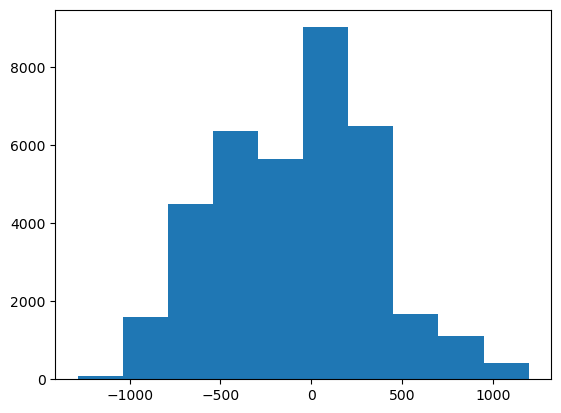

2735 obs within a 20 days of a TNS obs
2590 obs after 2023
2349 obs in sparse locations
576 obs with a ref of matching field and band
(1773 solo obs)


In [4]:

    
df_nonempty=df.copy()
# df_nonempty['min_dt'] = df_nonempty['dt'].apply(lambda x: min(map(abs, x)) if x else float('inf'))
df_nonempty['min_dt'] = df_nonempty['dt'].apply(lambda x: min(x, key=abs) if x else None)


sorted_ids = df_nonempty.sort_values('min_dt')
import matplotlib.pyplot as plt
plt.hist(sorted_ids['min_dt'])
plt.show()

close_obs = sorted_ids[np.abs(sorted_ids['min_dt'])<21]
print(len(close_obs), "obs within a 20 days of a TNS obs")

start_date = datetime(2024, 1, 1, 0, 0, 0)
close_obs = close_obs[close_obs['discovery_date']>start_date]
print(len(close_obs), "obs after 2023")

close_obs = gen_util.add_galactic_coords(close_obs)
close_obs = close_obs[abs(close_obs['b'])>16]
print(len(close_obs), "obs in sparse locations")

# close_obs = close_obs[close_obs['discoverymag']<19.5]
# print(len(close_obs), "obs brighter than 19.5")

def count_refs(row):
    if row['min_dt']>8:
        return 0
    
    min_idx = np.argmin(list(map(abs, row['dt'])))
    sci_key = (row['grid_field'][min_idx], row['band'][min_idx])
    all_keys = list(zip(row['grid_field'], row['band']))

    return sum(k == sci_key for i, k in enumerate(all_keys) if i != min_idx)

close_obs['ref_match_count'] = close_obs.apply(count_refs, axis=1)
del close_obs['grid_field']


solo_field = close_obs[close_obs['ref_match_count'] == 0]
multi_field = close_obs[close_obs['ref_match_count'] > 0]

print(len(multi_field), "obs with a ref of matching field and band")
print(f"({len(solo_field)} solo obs)")


top_hits_df = close_obs 

### Compare with previously observed and reduced data

In [5]:
list(multi_field["full_name"][100:])
recent_obs = pd.read_csv("data_results/single_detection_8_20.csv")
old_triplet = pd.read_csv("data_results/full_data.csv")

multi_field_new = multi_field[multi_field["full_name"].isin(recent_obs["full_name"])]
multi_field_old = multi_field[multi_field["full_name"].isin(old_triplet["full_name"])]
print(len(multi_field_new), "new obs, ", len(multi_field_old), "old obs,",len(multi_field), "total")


multi_field_target = multi_field #pd.concat([multi_field_new, multi_field_old])


89 new obs,  96 old obs, 576 total


In [6]:
multi_field_target[['discoverymag', 'full_name', 'dt', 'field', 'band', 'discovery_date', 'min_dt']].head()

,discoverymag,full_name,dt,field,band,discovery_date,min_dt
11214,22.6619,AT2025opd,"[-292, -20, -51]","[field13676-2026-01-12, field13676-2025-04-15,...","[J, J, J]",2025-03-26,-20.0
11231,22.3010,AT2025hrx,"[-41, -39, -292, -20]","[field13362-2025-05-06, field13362-2025-05-04,...","[J, J, J, J]",2025-03-26,-20.0
27040,21.7900,AT2025xef,"[-142, -139, -20]","[field16069-2025-12-17, field16069-2025-12-14,...","[J, J, J]",2025-07-28,-20.0
58074,18.7168,AT2025rpv,"[-181, -20]","[field9850-2025-12-17, field9850-2025-07-09]","[J, J]",2025-06-19,-20.0
22450,18.9000,AT2025xxl,"[-115, -20]","[field4457-2026-01-10, field4457-2025-10-07]","[J, J]",2025-09-17,-20.0


### Restructure data into a list of obervations, and save combo commands output file

In [7]:
by_obs = []

multi_field_target['truncated_field'] = [[field[:-11] for field in row['field']] for i, row in multi_field_target.iterrows()]

for j, row in multi_field_target.iterrows():
    # if row['min_dt']>8:
        # continue
    # print(row['dt'])
        
    sci_idx = np.argmin(list(map(abs, row['dt'])))
    sci_field = row['truncated_field'][sci_idx]
    sci_band = row['band'][sci_idx]

    # REF = obs with matching field and band that has the smallest dt
    
    
    matching_ref_idx = []
    ref_idxs = np.argsort(list(map(abs, row['dt'])))
    ref_idx = -1
    for i in ref_idxs:
        sci = i == sci_idx

        # change this to include only one ref 
        ref = row['truncated_field'][i] == sci_field and row['band'][i] == sci_band and i!=sci_idx 
        if sci or ref:
            try:
                new_row = row.copy()
                new_row['field'] = row['field'][i]
                new_row['dt'] = row['dt'][i]
                new_row['command'] = row['command'][i]
                by_obs.append(new_row)
                if ref: 
                    ref_idx = i
            except:
                print("ERROR")
            
# finding sci even if no ref         
by_obs = pd.DataFrame(by_obs)


/tmp/ipykernel_669181/2214372096.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_field_target['truncated_field'] = [[field[:-11] for field in row['field']] for i, row in multi_field_target.iterrows()]


In [8]:
print(len(by_obs))
by_obs.head()

1724


,objid,name_prefix,full_name,name,ra,declination,redshift,typeid,type,reporting_groupid,...,discovery_date,dt,field,band,command,min_dt,l,b,ref_match_count,truncated_field
11214,182276.0,AT,AT2025opd,2025opd,161.500842,-7.675104,NaN,NaN,NaN,114.0,...,2025-03-26,-20,field13676-2025-04-15,"[J, J, J]",target ...,-20.0,257.315473,43.810621,1,"[field13676, field13676, field13990]"
11214,182276.0,AT,AT2025opd,2025opd,161.500842,-7.675104,NaN,NaN,NaN,114.0,...,2025-03-26,-292,field13676-2026-01-12,"[J, J, J]",target ...,-20.0,257.315473,43.810621,1,"[field13676, field13676, field13990]"
11231,177470.0,AT,AT2025hrx,2025hrx,159.495523,-8.895567,NaN,NaN,NaN,114.0,...,2025-03-26,-20,field13674-2025-04-15,"[J, J, J, J]",target ...,-20.0,256.335545,41.595037,1,"[field13362, field13362, field13674, field13674]"
11231,177470.0,AT,AT2025hrx,2025hrx,159.495523,-8.895567,NaN,NaN,NaN,114.0,...,2025-03-26,-292,field13674-2026-01-12,"[J, J, J, J]",target ...,-20.0,256.335545,41.595037,1,"[field13362, field13362, field13674, field13674]"
27040,188278.0,AT,AT2025xef,2025xef,13.845099,0.459180,NaN,NaN,NaN,4.0,...,2025-07-28,-20,field16069-2025-08-17,"[J, J, J]",target ...,-20.0,125.059388,-62.396281,2,"[field16069, field16069, field16069]"


In [9]:

new_file_path = 'data_results/combo_commands_2026-09-03-top-candidates'

with open(new_file_path, 'w') as f_out:
    for command_list in by_obs['command']:
            command_dict = dict(command_list)
            
            # print(mydict)
            f_out.write(str(command_dict) + '\n')

print("DONE!")
            

DONE!
